# Stock Price Forecasting with LSTM

This notebook builds an end-to-end stock forecasting workflow using **yfinance**, technical indicators, preprocessing, an LSTM model, evaluation, and 15-step forecasting. The notebook prompts the user for ticker, date range, and interval at runtime, which matches a reusable yfinance download workflow using `start`, `end`, and `interval` parameters.[web:17][web:33]

The preprocessing and modeling flow follows standard TensorFlow time-series guidance: preserve chronological order, normalize numeric features, and convert the data into sliding windows for recurrent forecasting models.[web:9]

## 1. Install and import libraries

Run the next cell once if your environment does not already have the required packages.

In [1]:

%pip install yfinance pandas numpy matplotlib scikit-learn tensorflow seaborn

  Using cached websockets-16.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached cffi-2.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 1.8 MB/s  0:02:16m0:00:0100:04m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 2.6 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.4 MB/s

In [2]:
import warnings
warnings.filterwarnings('ignore')

import math
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('deep')

## 2. Prompt the user for inputs

This notebook asks the user to enter the stock ticker, start date, end date, and interval directly in code so the workflow can be reused for different securities and timeframes.[web:17][web:33]

In [3]:
VALID_INTERVALS = {
    '1m', '2m', '5m', '15m', '30m', '60m', '90m',
    '1h', '1d', '5d', '1wk', '1mo', '3mo'
}


def get_user_inputs():
    while True:
        ticker = input('Enter stock ticker (e.g., AAPL, MSFT, TSLA): ').strip().upper()
        start_date = input('Enter start date (YYYY-MM-DD): ').strip()
        end_date = input('Enter end date (YYYY-MM-DD): ').strip()
        interval = input('Enter interval (e.g., 1d, 1wk, 1mo, 1h): ').strip()

        if not ticker:
            print('Ticker cannot be empty. Please try again.')
            continue

        try:
            start_dt = datetime.strptime(start_date, '%Y-%m-%d')
            end_dt = datetime.strptime(end_date, '%Y-%m-%d')
        except ValueError:
            print('Dates must be in YYYY-MM-DD format. Please try again.')
            continue

        if start_dt >= end_dt:
            print('Start date must be earlier than end date. Please try again.')
            continue

        if interval not in VALID_INTERVALS:
            print(f'Interval must be one of: {sorted(VALID_INTERVALS)}')
            continue

        return ticker, start_date, end_date, interval


ticker, start_date, end_date, interval = get_user_inputs()
print(f'Selected -> Ticker: {ticker}, Start: {start_date}, End: {end_date}, Interval: {interval}')

Selected -> Ticker: AAPL, Start: 2025-07-01, End: 2026-06-29, Interval: 1d


## 3. Download historical stock data

The `yfinance.download` function supports historical downloads with `start`, `end`, `interval`, and `auto_adjust` controls. With `auto_adjust=True`, OHLC values are automatically adjusted, which is useful when you want a split- and dividend-adjusted price series for analysis.[web:33][web:28]

In [4]:
def download_stock_data(ticker, start_date, end_date, interval):
    data = yf.download(
        tickers=ticker,
        start=start_date,
        end=end_date,
        interval=interval,
        auto_adjust=True,
        progress=False,
        group_by='column'
    )

    if data.empty:
        raise ValueError('No data returned. Try a different ticker, date range, or interval.')

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]

    data = data.reset_index()
    date_col = 'Datetime' if 'Datetime' in data.columns else 'Date'
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col).reset_index(drop=True)
    return data, date_col


df, date_col = download_stock_data(ticker, start_date, end_date, interval)
df.head()

,Date,Close,High,Low,Open,Volume
0,2025-07-01,206.998795,209.359425,205.325425,205.853330,78788900
1,2025-07-02,211.600540,212.496978,207.317529,208.084490,67941800
2,2025-07-03,212.706146,213.801790,210.973016,211.311669,34955800
3,2025-07-07,209.120361,215.375544,207.974912,211.839569,50229000
4,2025-07-08,209.180130,210.594517,207.626297,209.269786,42848900


## 4. Create adjusted close series and technical indicators

This project uses three common indicators: EMA-based MACD, RSI, and Bollinger Bands. These are widely used to capture momentum, relative strength, and volatility around the price series, which adds signal beyond raw price alone.[web:9][web:34]

In [5]:
def add_technical_indicators(data):
    df = data.copy()
    price_col = 'Close'

    df['Adj_Close'] = df[price_col]

    df['EMA_12'] = df['Adj_Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Adj_Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    delta = df['Adj_Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df['RSI'] = 100 - (100 / (1 + rs))

    df['SMA_20'] = df['Adj_Close'].rolling(window=20).mean()
    rolling_std = df['Adj_Close'].rolling(window=20).std()
    df['BB_Upper'] = df['SMA_20'] + 2 * rolling_std
    df['BB_Lower'] = df['SMA_20'] - 2 * rolling_std

    df = df.dropna().reset_index(drop=True)
    return df


df = add_technical_indicators(df)
df.head()

,Date,Close,High,Low,Open,Volume,Adj_Close,EMA_12,EMA_26,MACD,MACD_Signal,RSI,SMA_20,BB_Upper,BB_Lower
0,2025-07-29,210.435150,213.961155,209.986931,213.333639,51411700,210.435150,211.467622,210.290811,1.176811,1.090329,50.438301,210.741941,214.726605,206.757277
1,2025-07-30,208.223923,211.550721,206.899177,211.062652,45512500,208.223923,210.968591,210.137708,0.830883,1.038440,39.353518,210.803197,214.577699,207.028696
2,2025-07-31,206.749786,209.010805,206.341403,207.666149,80698400,206.749786,210.319544,209.886751,0.432793,0.917311,38.788227,210.560660,214.722908,206.398412
3,2025-08-01,201.580292,212.736031,200.703764,210.036733,104434500,201.580292,208.975044,209.271458,-0.296414,0.674566,33.279669,210.004367,215.663921,204.344813
4,2025-08-04,202.546463,207.058561,200.883049,203.701868,75109300,202.546463,207.986031,208.773310,-0.787278,0.382197,34.952965,209.675672,216.242306,203.109039


## 5. Visualize stock price and indicators

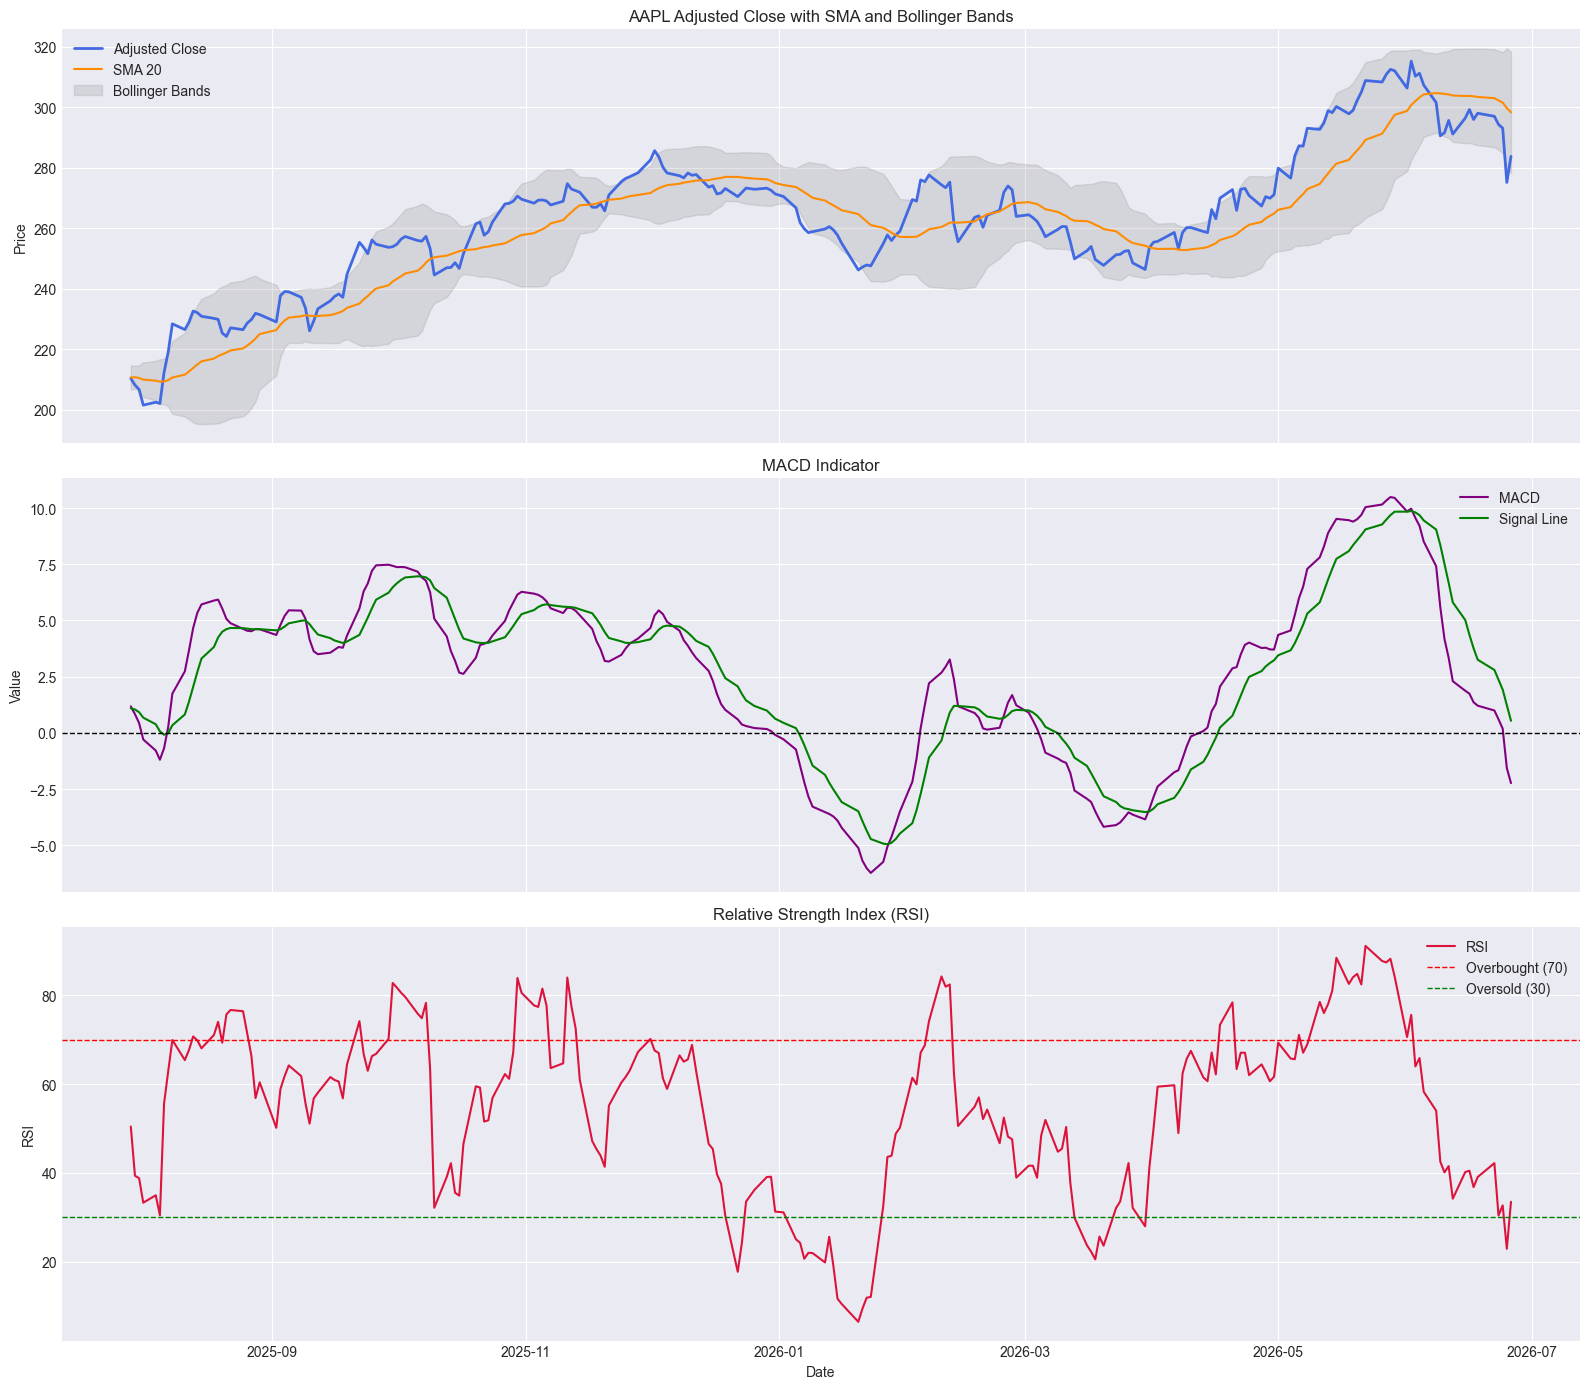

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].plot(df[date_col], df['Adj_Close'], label='Adjusted Close', color='royalblue', linewidth=2)
axes[0].plot(df[date_col], df['SMA_20'], label='SMA 20', color='darkorange', linewidth=1.5)
axes[0].fill_between(df[date_col], df['BB_Lower'], df['BB_Upper'], color='gray', alpha=0.2, label='Bollinger Bands')
axes[0].set_title(f'{ticker} Adjusted Close with SMA and Bollinger Bands')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].plot(df[date_col], df['MACD'], label='MACD', color='purple', linewidth=1.5)
axes[1].plot(df[date_col], df['MACD_Signal'], label='Signal Line', color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('MACD Indicator')
axes[1].set_ylabel('Value')
axes[1].legend()

axes[2].plot(df[date_col], df['RSI'], label='RSI', color='crimson', linewidth=1.5)
axes[2].axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].set_title('Relative Strength Index (RSI)')
axes[2].set_ylabel('RSI')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Preprocess the data for the LSTM model

The feature set is normalized with `MinMaxScaler`, and the sequence builder uses a sliding window of 60 steps. Windowing sequential data is a standard preparation step for recurrent forecasting models.[web:9]

In [7]:
feature_columns = ['Adj_Close', 'MACD', 'RSI', 'SMA_20', 'BB_Upper', 'BB_Lower']
window_size = 60
forecast_horizon = 15

model_df = df[[date_col] + feature_columns].copy()

split_index = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[feature_columns])

scaled_features = feature_scaler.transform(model_df[feature_columns])
scaled_df = pd.DataFrame(scaled_features, columns=feature_columns)
scaled_df[date_col] = model_df[date_col].values


def create_sequences(data_array, window_size, target_index=0):
    X, y = [], []
    for i in range(window_size, len(data_array)):
        X.append(data_array[i-window_size:i])
        y.append(data_array[i, target_index])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_df[feature_columns].values, window_size, target_index=0)
all_dates = model_df[date_col].iloc[window_size:].reset_index(drop=True)

train_sequence_end = split_index - window_size
X_train, y_train = X_all[:train_sequence_end], y_all[:train_sequence_end]
X_test, y_test = X_all[train_sequence_end:], y_all[train_sequence_end:]
test_dates = all_dates.iloc[train_sequence_end:].reset_index(drop=True)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (124, 60, 6)
X_test shape: (46, 60, 6)


## 7. Build and train the LSTM model

This notebook uses Keras LSTM layers with dropout regularization and early stopping. TensorFlow’s time-series documentation highlights recurrent models as one option for sequence forecasting once data has been transformed into consecutive windows.[web:9]

In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.3339 - val_loss: 0.0059
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0617 - val_loss: 0.0184
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0336 - val_loss: 0.0238
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0327 - val_loss: 0.0414
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0325 - val_loss: 0.0143
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0198 - val_loss: 0.0025
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0243 - val_loss: 0.0023
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0155 - val_loss: 0.0100
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0165 - val_loss: 0.0156
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0182 - val_loss: 0.0093
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0125 - val_loss: 0.0040
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0129 - val_loss: 0.0040
E

## 8. Evaluate model performance

The notebook evaluates the forecast using RMSE, MAE, and the coefficient of determination, R-squared. The R-squared formula used is:

\[
R^2 = 1 - 
rac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - ar{y})^2}
\]

In [9]:
def invert_target_scale(scaled_target_values, scaler, feature_columns, target_col='Adj_Close'):
    temp = np.zeros((len(scaled_target_values), len(feature_columns)))
    target_idx = feature_columns.index(target_col)
    temp[:, target_idx] = scaled_target_values.reshape(-1)
    inverted = scaler.inverse_transform(temp)
    return inverted[:, target_idx]

train_pred_scaled = model.predict(X_train, verbose=0)
test_pred_scaled = model.predict(X_test, verbose=0)

train_actual = invert_target_scale(y_train, feature_scaler, feature_columns)
train_pred = invert_target_scale(train_pred_scaled, feature_scaler, feature_columns)

test_actual = invert_target_scale(y_test, feature_scaler, feature_columns)
test_pred = invert_target_scale(test_pred_scaled, feature_scaler, feature_columns)

train_rmse = math.sqrt(mean_squared_error(train_actual, train_pred))
test_rmse = math.sqrt(mean_squared_error(test_actual, test_pred))
train_mae = mean_absolute_error(train_actual, train_pred)
test_mae = mean_absolute_error(test_actual, test_pred)
test_r2 = r2_score(test_actual, test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Test R^2'],
    'Value': [train_rmse, test_rmse, train_mae, test_mae, test_r2]
})
metrics_df

,Metric,Value
0,Train RMSE,8.539858
1,Test RMSE,15.534962
2,Train MAE,6.850537
3,Test MAE,13.209673
4,Test R^2,-0.369775


## 9. Visualize actual vs predicted values

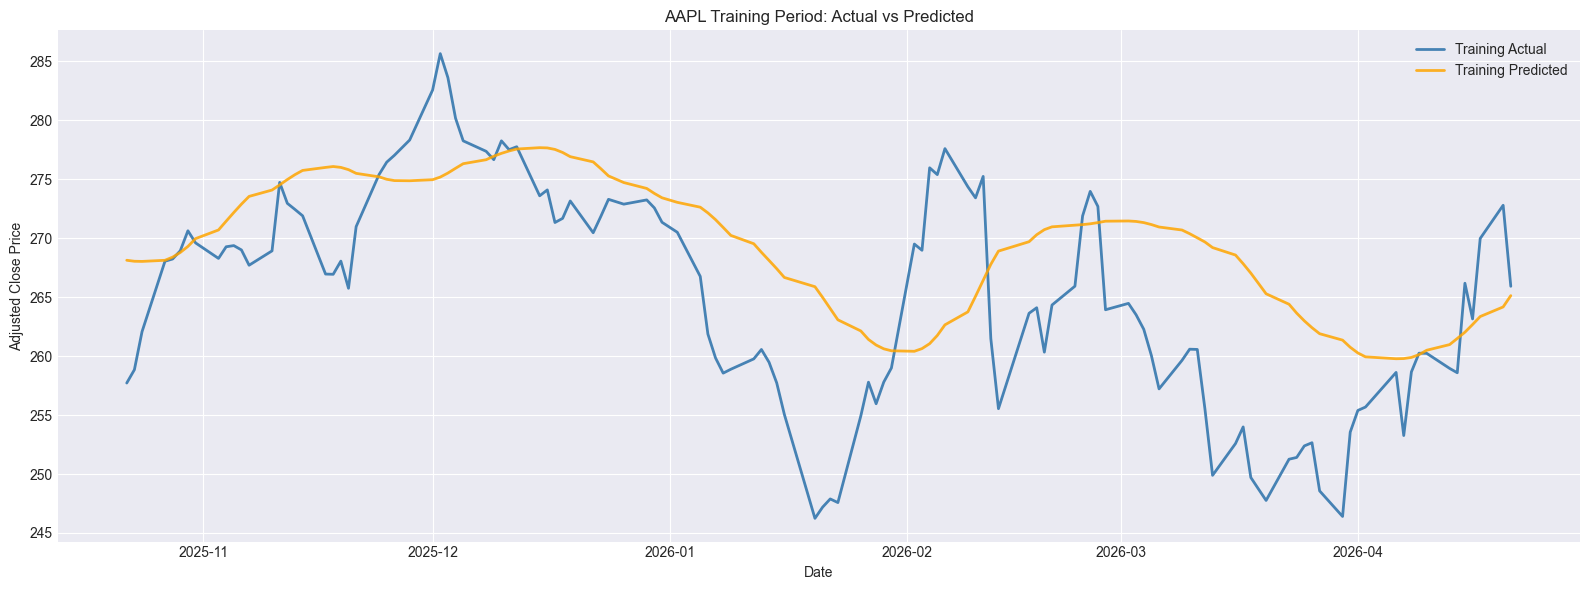

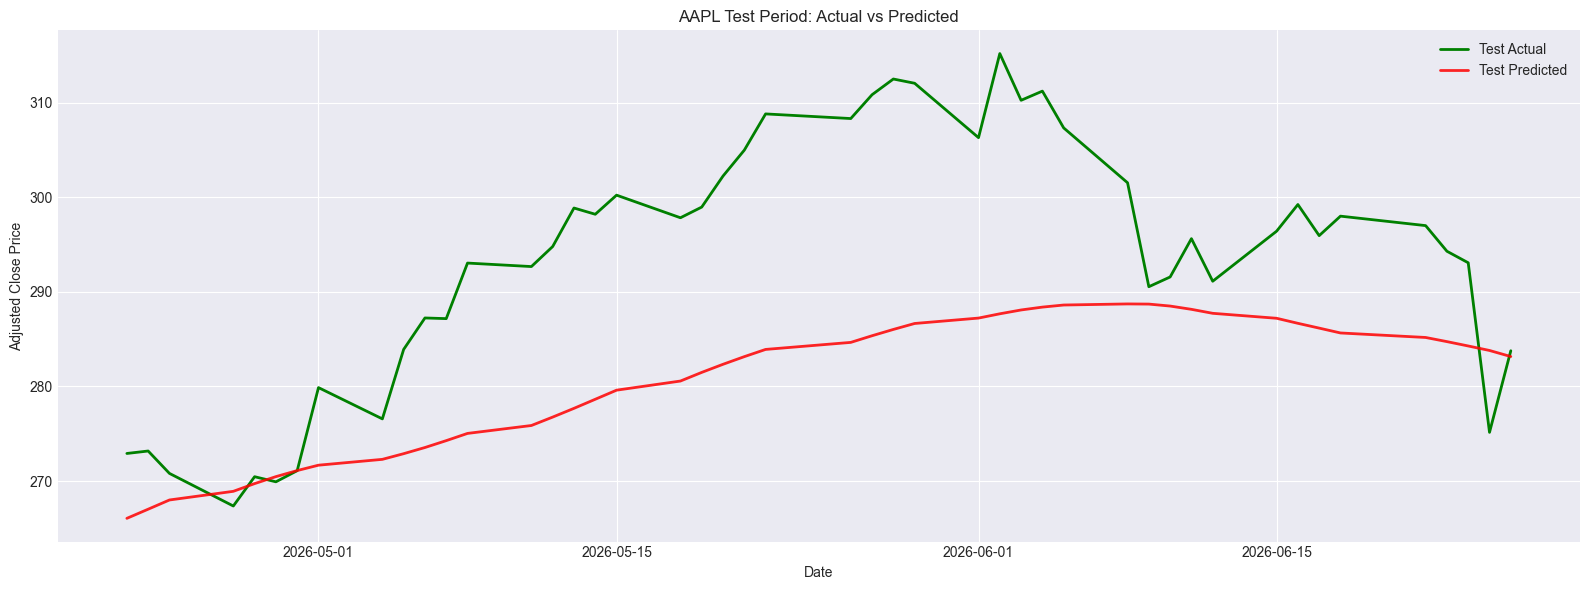

In [10]:
train_dates = all_dates.iloc[:train_sequence_end].reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(train_dates, train_actual, label='Training Actual', color='steelblue', linewidth=2)
plt.plot(train_dates, train_pred, label='Training Predicted', color='orange', linewidth=2, alpha=0.85)
plt.title(f'{ticker} Training Period: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
plt.plot(test_dates, test_actual, label='Test Actual', color='green', linewidth=2)
plt.plot(test_dates, test_pred, label='Test Predicted', color='red', linewidth=2, alpha=0.85)
plt.title(f'{ticker} Test Period: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Forecast the next 15 periods

The model generates a recursive multi-step forecast by feeding each prediction back into the most recent window. This is a common practical strategy when the model predicts one next value at a time.[web:9]

In [11]:
last_sequence = scaled_df[feature_columns].values[-window_size:].copy()
future_scaled_predictions = []
current_sequence = last_sequence.copy()

for _ in range(forecast_horizon):
    next_pred_scaled = model.predict(current_sequence.reshape(1, window_size, len(feature_columns)), verbose=0)[0, 0]
    future_scaled_predictions.append(next_pred_scaled)

    next_row = current_sequence[-1].copy()
    next_row[0] = next_pred_scaled
    current_sequence = np.vstack([current_sequence[1:], next_row])

future_predictions = invert_target_scale(np.array(future_scaled_predictions), feature_scaler, feature_columns)

last_timestamp = model_df[date_col].iloc[-1]
if interval in {'1d', '5d'}:
    future_dates = pd.bdate_range(start=last_timestamp + pd.Timedelta(days=1), periods=forecast_horizon)
elif interval == '1wk':
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(weeks=1), periods=forecast_horizon, freq='W')
elif interval in {'1mo', '3mo'}:
    freq = 'MS' if interval == '1mo' else 'QS'
    future_dates = pd.date_range(start=last_timestamp + pd.offsets.DateOffset(months=1), periods=forecast_horizon, freq=freq)
elif interval in {'1h', '60m'}:
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')
elif interval == '90m':
    future_dates = pd.date_range(start=last_timestamp + pd.Timedelta(minutes=90), periods=forecast_horizon, freq='90min')
else:
    minute_map = {'1m': '1min', '2m': '2min', '5m': '5min', '15m': '15min', '30m': '30min'}
    freq = minute_map.get(interval, 'D')
    start_dt = last_timestamp + pd.to_timedelta(freq)
    future_dates = pd.date_range(start=start_dt, periods=forecast_horizon, freq=freq)

forecast_df = pd.DataFrame({
    'Forecast_Date': future_dates,
    'Forecasted_Adj_Close': future_predictions
})
forecast_df

,Forecast_Date,Forecasted_Adj_Close
0,2026-06-29,282.523773
1,2026-06-30,281.938510
2,2026-07-01,281.408860
3,2026-07-02,280.917923
4,2026-07-03,280.472316
5,2026-07-06,280.074092
6,2026-07-07,279.722576
7,2026-07-08,279.415326
8,2026-07-09,279.149000
9,2026-07-10,278.919734


## 11. Visualize the 15-step forecast

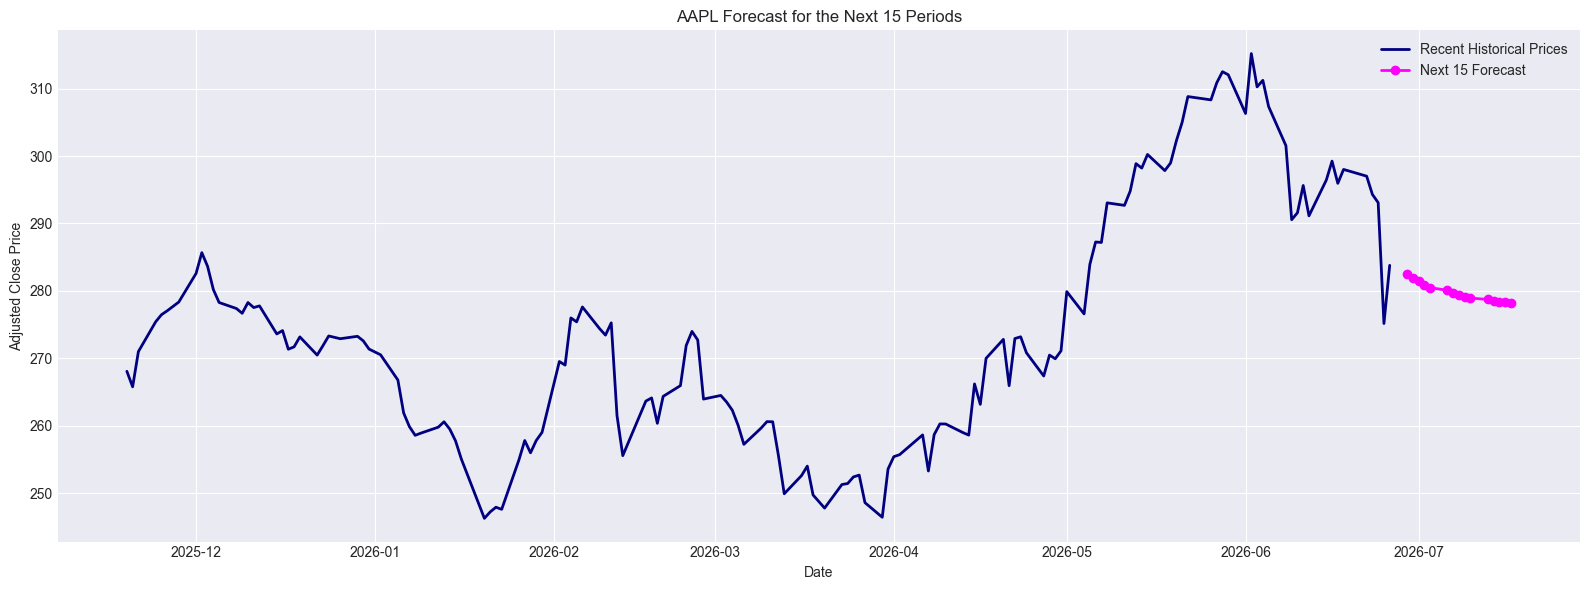

In [12]:
plt.figure(figsize=(16, 6))
plt.plot(model_df[date_col].tail(150), model_df['Adj_Close'].tail(150), label='Recent Historical Prices', color='navy', linewidth=2)
plt.plot(forecast_df['Forecast_Date'], forecast_df['Forecasted_Adj_Close'], label='Next 15 Forecast', color='magenta', linewidth=2, marker='o')
plt.title(f'{ticker} Forecast for the Next {forecast_horizon} Periods')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Save outputs

This cell exports processed data, metrics, and forecast results so they can be added to the GitHub repository alongside the notebook.

In [13]:
output_prefix = f"{ticker}_{interval}_{start_date}_to_{end_date}".replace(':', '-')

processed_path = f"{output_prefix}_processed_data.csv"
metrics_path = f"{output_prefix}_metrics.csv"
forecast_path = f"{output_prefix}_forecast.csv"

model_df.to_csv(processed_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
forecast_df.to_csv(forecast_path, index=False)

print('Saved files:')
print('-', processed_path)
print('-', metrics_path)
print('-', forecast_path)

Saved files:
- AAPL_1d_2025-07-01_to_2026-06-29_processed_data.csv
- AAPL_1d_2025-07-01_to_2026-06-29_metrics.csv
- AAPL_1d_2025-07-01_to_2026-06-29_forecast.csv
